# Does club wage spending predict Premier League finishing position? (2025-26)


**Research question.** Do clubs that spend more on player wages finish higher in the Premier League table?

**Student name:** Olzhabay Kuanysh

**ID:** 24B031954

| Source | How I collected it | What I got |
|---|---|---|
| football-data.org `/v4/competitions/PL/standings` | **API** (`requests`) | Final 2025-26 league table (position, points, goals) |
| FBref "Squad Wages" table (payroll data from Capology) | **Web scraping** (`requests` + `BeautifulSoup`) | Weekly and annual wage bill of each club |

**Pipeline:** 1. Collect → 2. Clean → 3. Merge → 4. Analyse (EDA) → 5. Visualise → 6. Conclusions

In [19]:
import json
import os
import re
import urllib.robotparser
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup, Comment
from scipy import stats

DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 150)

## 1. Data collection

### 1.1 API: football-data.org (league table)
We call the `standings` endpoint for season 2025 (= 2025-26). The API needs a free token, which we read from the
environment variable `FOOTBALL_DATA_TOKEN` (so the key is never stored in the notebook).
The raw response is saved to `data/standings_raw.json`; if the live call fails, the saved copy is used instead.

In [20]:
API_URL = "https://api.football-data.org/v4/competitions/PL/standings"
API_TOKEN = os.getenv("FOOTBALL_DATA_TOKEN", "")
RAW_JSON = DATA_DIR / "standings_raw.json"


def get_standings():
    headers = {"X-Auth-Token": API_TOKEN} if API_TOKEN else {}
    try:
        resp = requests.get(API_URL, headers=headers, params={"season": 2025}, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        RAW_JSON.write_text(json.dumps(data), encoding="utf-8")
        print("Fetched live from the API and saved a copy.")
    except (requests.RequestException, ValueError) as err:
        print(f"Live API call failed ({type(err).__name__}); using the saved response in {RAW_JSON}.")
        data = json.loads(RAW_JSON.read_text(encoding="utf-8"))
    return data


standings_json = get_standings()
print("Competition:", standings_json["competition"]["code"], "| matchday:", standings_json["season"]["currentMatchday"])

total_table = next(s for s in standings_json["standings"] if s["type"] == "TOTAL")["table"]
df_api = pd.json_normalize(total_table)
df_api.head()

Fetched live from the API and saved a copy.
Competition: PL | matchday: 38


,position,playedGames,form,won,draw,lost,points,goalsFor,goalsAgainst,goalDifference,team.id,team.name,team.shortName,team.tla,team.crest
0,1,38,"W,W,W,W,W",26,7,5,85,71,27,44,57,Arsenal FC,Arsenal,ARS,https://crests.football-data.org/57.png
1,2,38,"L,D,W,W,D",23,9,6,78,77,35,42,65,Manchester City FC,Man City,MCI,https://crests.football-data.org/65.png
2,3,38,"W,W,D,W,W",20,11,7,71,69,50,19,66,Manchester United FC,Man United,MUN,https://crests.football-data.org/66.png
3,4,38,"W,W,D,L,L",19,8,11,65,56,49,7,58,Aston Villa FC,Aston Villa,AVL,https://crests.football-data.org/58.png
4,5,38,"D,L,D,L,W",17,9,12,60,63,53,10,64,Liverpool FC,Liverpool,LIV,https://crests.football-data.org/64.png


### 1.2 Web scraping: FBref "Squad Wages" table
Steps: (1) check `robots.txt`, (2) request the page, (3) find the table with BeautifulSoup and read every row.


In [21]:
FBREF_URL = "https://fbref.com/en/comps/9/2025-2026/wages/2025-2026-Premier-League-Wages"
HTML_FILE = DATA_DIR / "fbref_wages.html"
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) "
                         "Chrome/124.0 Safari/537.36",
           "Accept-Language": "en-US,en;q=0.9"}

try:
    robots = requests.get("https://fbref.com/robots.txt", headers=HEADERS, timeout=30)
    if robots.status_code == 200:
        rp = urllib.robotparser.RobotFileParser()
        rp.parse(robots.text.splitlines())
        print("robots.txt allows this page:", rp.can_fetch("*", FBREF_URL))
    else:
        print("robots.txt not readable, HTTP", robots.status_code)
except requests.RequestException as err:
    print("robots.txt check skipped:", type(err).__name__)


def get_fbref_html():
    try:
        resp = requests.get(FBREF_URL, headers=HEADERS, timeout=30)
        if resp.status_code == 200 and "Weekly Wages" in resp.text:
            HTML_FILE.write_text(resp.text, encoding="utf-8")
            print("Scraped the live page and saved a copy.")
            return resp.text
        print(f"Live request not usable (HTTP {resp.status_code}) - bot protection.")
    except requests.RequestException as err:
        print(f"Live request failed ({type(err).__name__}).")
    if HTML_FILE.exists():
        print(f"Using the page saved from the browser: {HTML_FILE}")
        return HTML_FILE.read_text(encoding="utf-8")
    raise FileNotFoundError(f"Open {FBREF_URL} in a browser, press Ctrl+S and save it as {HTML_FILE}")


html = get_fbref_html()

robots.txt not readable, HTTP 403
Live request not usable (HTTP 403) - bot protection.
Using the page saved from the browser: data\fbref_wages.html


In [22]:
def parse_wages_table(html):
    soup = BeautifulSoup(html, "html.parser")
    tables = soup.find_all("table")
    for comment in soup.find_all(string=lambda s: isinstance(s, Comment)):
        if "<table" in comment:
            tables += BeautifulSoup(comment, "html.parser").find_all("table")

    for table in tables:
        header_rows = table.select("thead tr") or table.find_all("tr")[:1]
        header = [c.get_text(" ", strip=True) for c in header_rows[-1].find_all(["th", "td"])]
        if "Squad" in header and "Weekly Wages" in header:
            rows = []
            for tr in table.find_all("tr"):
                cells = [c.get_text(" ", strip=True) for c in tr.find_all(["th", "td"])]
                if len(cells) == len(header) and cells[0] != header[0]:
                    rows.append(cells)
            return pd.DataFrame(rows, columns=header)
    raise ValueError("Squad Wages table not found in the HTML")


df_fbref = parse_wages_table(html)
print(df_fbref.shape)
df_fbref.head()

(20, 6)


,Rk,Squad,# Pl,Weekly Wages,Annual Wages,% Estimated
0,1,Manchester City,72,"£ 4,305,300 (€ 4,987,567, $5,890,919)","£ 223,875,600 (€ 259,353,477, $306,327,780)",57%
1,2,Arsenal,53,"£ 3,641,000 (€ 4,217,994, $4,981,961)","£ 189,332,000 (€ 219,335,703, $259,061,960)",60%
2,3,Liverpool,65,"£ 3,430,400 (€ 3,974,020, $4,693,798)","£ 178,380,800 (€ 206,649,053, $244,077,489)",59%
3,4,Manchester Utd,78,"£ 3,121,750 (€ 3,616,458, $4,271,474)","£ 162,331,000 (€ 188,055,822, $222,116,632)",44%
4,5,Chelsea,67,"£ 3,006,500 (€ 3,482,944, $4,113,778)","£ 156,338,000 (€ 181,113,101, $213,916,445)",54%


## 2. Data cleaning
Both datasets are cleaned separately

### 2.1 League table (API)

In [23]:
standings = (
    df_api.rename(columns={"team.name": "team_name", "team.tla": "tla", "playedGames": "played",
                           "goalsFor": "goals_for", "goalsAgainst": "goals_against",
                           "goalDifference": "goal_diff"})
    [["position", "team_name", "tla", "played", "won", "draw", "lost",
      "points", "goals_for", "goals_against", "goal_diff"]]
    .copy()
)

standings["club"] = standings["team_name"].str.replace(r"^AFC\s+|\s+A?FC$", "", regex=True)

print("Missing values:", int(standings.isna().sum().sum()), "| duplicate clubs:",
      int(standings["tla"].duplicated().sum()))
print(standings.dtypes.value_counts().to_dict())
standings[["position", "club", "tla", "points", "goal_diff"]].head(3)

Missing values: 0 | duplicate clubs: 0
{dtype('int64'): 9, <StringDtype(storage='python', na_value=nan)>: 3}


,position,club,tla,points,goal_diff
0,1,Arsenal,ARS,85,44
1,2,Manchester City,MCI,78,42
2,3,Manchester United,MUN,71,19


### 2.2 Wage bills (scraped)

In [24]:
def gbp_to_int(text):
    """'£ 4,305,300 (€ 4,987,567, $5,890,919)' -> 4305300"""
    m = re.search(r"£\s*([\d,]+)", text)
    return int(m.group(1).replace(",", "")) if m else np.nan


wages = df_fbref.rename(columns={"Squad": "club_fbref", "# Pl": "players_used", "Weekly Wages": "weekly_raw",
                                 "Annual Wages": "annual_raw", "% Estimated": "pct_estimated"}).copy()

wages["club_fbref"] = wages["club_fbref"].str.replace(r"^Club Crest\s*", "", regex=True).str.strip()
wages["weekly_wages"] = wages["weekly_raw"].map(gbp_to_int)
wages["annual_wages"] = wages["annual_raw"].map(gbp_to_int)
wages["players_used"] = pd.to_numeric(wages["players_used"], errors="coerce")
wages["pct_estimated"] = pd.to_numeric(wages["pct_estimated"].str.rstrip("%"), errors="coerce")
wages["annual_wages_m"] = wages["annual_wages"] / 1e6

ALIASES = {
    "arsenal": "ARS", "aston villa": "AVL", "bournemouth": "BOU", "brentford": "BRE",
    "brighton": "BHA", "brighton & hove albion": "BHA", "burnley": "BUR", "chelsea": "CHE",
    "crystal palace": "CRY", "everton": "EVE", "fulham": "FUL", "leeds united": "LEE", "leeds": "LEE",
    "liverpool": "LIV", "manchester city": "MCI", "manchester utd": "MUN", "manchester united": "MUN",
    "newcastle": "NEW", "newcastle utd": "NEW", "newcastle united": "NEW",
    "nottingham": "NOT", "nott'ham forest": "NOT", "nottingham forest": "NOT", "sunderland": "SUN",
    "tottenham": "TOT", "tottenham hotspur": "TOT", "west ham": "WHU", "west ham united": "WHU",
    "wolves": "WOL", "wolverhampton": "WOL", "wolverhampton wanderers": "WOL",
}
wages["tla"] = wages["club_fbref"].str.lower().map(ALIASES)
wages = wages[["tla", "club_fbref", "players_used", "weekly_wages", "annual_wages", "annual_wages_m", "pct_estimated"]]

print("Unmatched club names:", wages.loc[wages["tla"].isna(), "club_fbref"].tolist())
print("Missing values:", int(wages.isna().sum().sum()), "| duplicate clubs:", int(wages["tla"].duplicated().sum()))
print("Annual = 52 x weekly for every club:",
      bool(np.allclose(wages["annual_wages"] / wages["weekly_wages"], 52, atol=0.1)))
wages.head(3)

Unmatched club names: []
Missing values: 0 | duplicate clubs: 0
Annual = 52 x weekly for every club: True


,tla,club_fbref,players_used,weekly_wages,annual_wages,annual_wages_m,pct_estimated
0,MCI,Manchester City,72,4305300,223875600,223.8756,57
1,ARS,Arsenal,53,3641000,189332000,189.3320,60
2,LIV,Liverpool,65,3430400,178380800,178.3808,59


## 3. Merging
The two tables are joined on the club code (`tla`). Every club must appear exactly once in both tables (`one_to_one`), giving 20 rows.

In [25]:
df = standings.merge(wages, on="tla", how="inner", validate="one_to_one")
assert len(df) == 20, f"Expected 20 clubs after merge, got {len(df)}"

df["wage_rank"] = df["annual_wages"].rank(ascending=False, method="min").astype(int)
df["rank_gap"] = df["wage_rank"] - df["position"]
df["wage_per_point_m"] = df["annual_wages_m"] / df["points"]

df = df.sort_values("position").reset_index(drop=True)
df[["position", "club", "points", "annual_wages_m", "wage_rank", "rank_gap"]]

,position,club,points,annual_wages_m,wage_rank,rank_gap
0,1,Arsenal,85,189.3320,2,1
1,2,Manchester City,78,223.8756,1,-1
2,3,Manchester United,71,162.3310,4,1
3,4,Aston Villa,65,129.5372,7,3
4,5,Liverpool,60,178.3808,3,-2
5,6,Bournemouth,57,62.7640,16,10
6,7,Sunderland,54,68.0160,15,8
7,8,Brighton & Hove Albion,53,60.9050,17,9
8,9,Brentford,53,54.3010,20,11
9,10,Chelsea,52,156.3380,5,-5


## 4. Exploratory data analysis

In [26]:
cols = ["annual_wages_m", "points", "position", "goal_diff", "wage_per_point_m"]
df[cols].describe().round(1)

,annual_wages_m,points,position,goal_diff,wage_per_point_m
count,20.0,20.0,20.0,20.0,20.0
mean,106.1,51.8,10.5,0.0,2.1
std,51.7,15.8,5.9,20.5,0.8
min,54.3,20.0,1.0,-41.0,1.0
25%,66.7,44.8,5.8,-7.5,1.4
50%,81.8,52.0,10.5,-2.5,2.2
75%,138.8,57.8,15.2,6.2,2.6
max,223.9,85.0,20.0,44.0,3.6


In [27]:
# Correlations between wage spending and results
r_pts, p_pts = stats.pearsonr(df["annual_wages_m"], df["points"])
r_log, p_log = stats.pearsonr(np.log(df["annual_wages_m"]), df["points"])
r_gd, p_gd = stats.pearsonr(df["annual_wages_m"], df["goal_diff"])
rho, p_rho = stats.spearmanr(df["wage_rank"], df["position"])
reg = stats.linregress(df["annual_wages_m"], df["points"])

corr = pd.DataFrame({
    "pair": ["Wages vs points (Pearson)", "log(Wages) vs points (Pearson)",
             "Wages vs goal difference (Pearson)", "Wage rank vs final position (Spearman)"],
    "coefficient": [r_pts, r_log, r_gd, rho],
    "p_value": [p_pts, p_log, p_gd, p_rho],
}).round(3)
print(corr.to_string(index=False))
print(f"\nRegression: points = {reg.intercept:.1f} + {reg.slope:.2f} x wages(£m)   R² = {reg.rvalue ** 2:.2f}")

                                  pair  coefficient  p_value
             Wages vs points (Pearson)        0.682    0.001
        log(Wages) vs points (Pearson)        0.639    0.002
    Wages vs goal difference (Pearson)        0.734    0.000
Wage rank vs final position (Spearman)        0.456    0.043

Regression: points = 29.7 + 0.21 x wages(£m)   R² = 0.47


In [28]:
# Who beat / missed their wage bill?
print("Biggest over-performers (finished far above wage rank):")
print(
    df.nlargest(4, "rank_gap")[["club", "position", "wage_rank", "rank_gap", "annual_wages_m"]].to_string(index=False))
print("\nBiggest under-performers:")
print(
    df.nsmallest(4, "rank_gap")[["club", "position", "wage_rank", "rank_gap", "annual_wages_m"]].to_string(index=False))

# Big-spenders (top 6 wage bills) vs the rest
top6 = df["wage_rank"] <= 6
print("\nAverage points - top-6 wage bills:", round(df.loc[top6, "points"].mean(), 1),
      "| other 14 clubs:", round(df.loc[~top6, "points"].mean(), 1))
print("Cheapest cost per point:", df.nsmallest(1, "wage_per_point_m")["club"].item(),
      "| most expensive:", df.nlargest(1, "wage_per_point_m")["club"].item())

Biggest over-performers (finished far above wage rank):
                  club  position  wage_rank  rank_gap  annual_wages_m
             Brentford         9         20        11          54.301
           Bournemouth         6         16        10          62.764
Brighton & Hove Albion         8         17         9          60.905
            Sunderland         7         15         8          68.016

Biggest under-performers:
                   club  position  wage_rank  rank_gap  annual_wages_m
      Tottenham Hotspur        17          6       -11        132.9120
        West Ham United        18         10        -8         86.1432
      Nottingham Forest        16          9        -7         92.6770
Wolverhampton Wanderers        20         13        -7         72.3580

Average points - top-6 wage bills: 64.5 | other 14 clubs: 46.4
Cheapest cost per point: Brentford | most expensive: Wolverhampton Wanderers


## 5. Visualisations

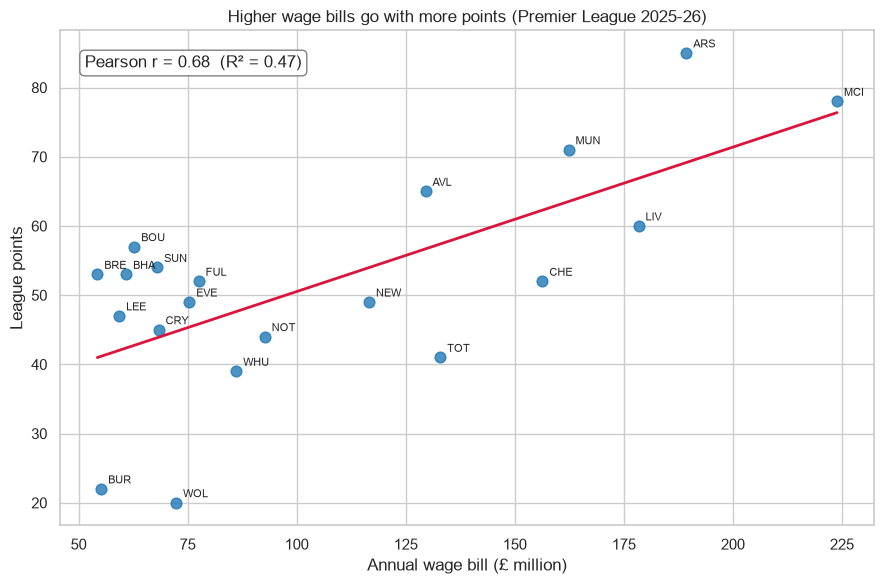

In [29]:
#  wage bill vs points
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=df, x="annual_wages_m", y="points", ci=None, ax=ax,
            scatter_kws={"s": 60, "color": "#1f77b4"}, line_kws={"color": "crimson", "lw": 2})
for _, r in df.iterrows():
    ax.annotate(r["tla"], (r["annual_wages_m"], r["points"]), xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.text(0.03, 0.95, f"Pearson r = {r_pts:.2f}  (R² = {reg.rvalue ** 2:.2f})", transform=ax.transAxes, va="top",
        bbox=dict(boxstyle="round", fc="white", ec="grey"))
ax.set(xlabel="Annual wage bill (£ million)", ylabel="League points",
       title="Higher wage bills go with more points (Premier League 2025-26)")
plt.tight_layout()
fig.savefig(FIG_DIR / "01_wages_vs_points.png", dpi=150)
plt.show()

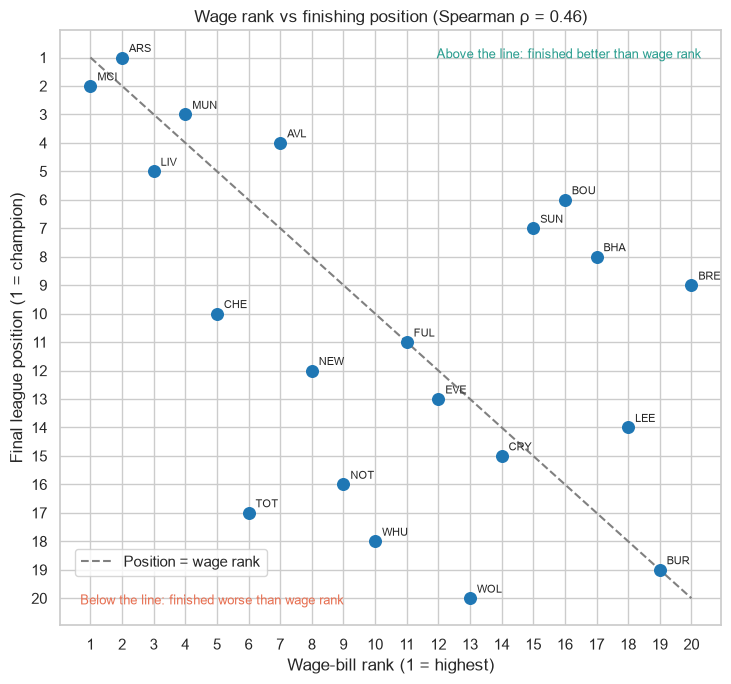

In [30]:
# wage rank vs final position (diagonal = "finish where your wages say")
fig, ax = plt.subplots(figsize=(7.5, 7))
ax.plot([1, 20], [1, 20], ls="--", color="grey", label="Position = wage rank")
ax.scatter(df["wage_rank"], df["position"], s=70, color="#1f77b4", zorder=3)
for _, r in df.iterrows():
    ax.annotate(r["tla"], (r["wage_rank"], r["position"]), xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.invert_yaxis()
ax.set_xticks(range(1, 21));
ax.set_yticks(range(1, 21))
ax.text(0.97, 0.97, "Above the line: finished better than wage rank", transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color="#2a9d8f")
ax.text(0.03, 0.03, "Below the line: finished worse than wage rank", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=9, color="#e76f51")
ax.set(xlabel="Wage-bill rank (1 = highest)", ylabel="Final league position (1 = champion)",
       title=f"Wage rank vs finishing position (Spearman ρ = {rho:.2f})")
ax.legend(loc="lower left", bbox_to_anchor=(0.01, 0.07))
plt.tight_layout()
fig.savefig(FIG_DIR / "02_wage_rank_vs_position.png", dpi=150)
plt.show()

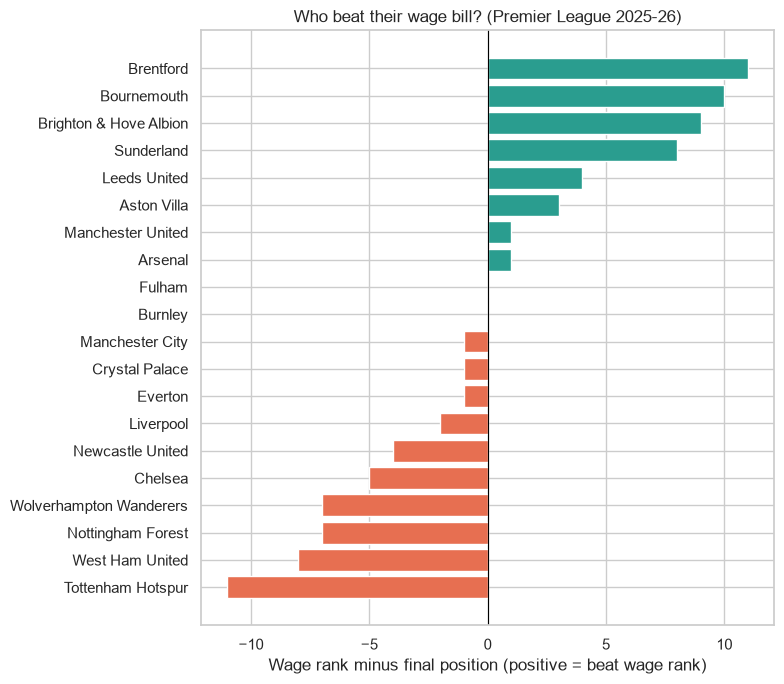

In [31]:
# over- and under-performers
order = df.sort_values("rank_gap")
colors = np.where(order["rank_gap"] > 0, "#2a9d8f", np.where(order["rank_gap"] < 0, "#e76f51", "grey"))
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(order["club"], order["rank_gap"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set(xlabel="Wage rank minus final position (positive = beat wage rank)", ylabel="",
       title="Who beat their wage bill? (Premier League 2025-26)")
plt.tight_layout()
fig.savefig(FIG_DIR / "03_over_under_performers.png", dpi=150)
plt.show()

## 6. Conclusions
**Answer: partly.** Wage spending is a meaningful predictor of *how many points* a club earns, but only a moderate predictor of the *exact finishing position*.

- **Clear positive link with points.** Wage bill vs points: Pearson r = 0.68 (p < 0.01), R² = 0.47, so wages alone explain about half of the variation in points. On average, every extra £10m of annual wages goes with about 2 more points.
- **Moderate link with position.** Wage rank vs final position: Spearman ρ = 0.46 (p ≈ 0.04). The top of the table is predicted well (the top 5 finishers all had a top-7 wage bill; the six biggest wage bills averaged 64.5 points vs 46.4 for the other 14 clubs). The middle is tightly packed, so small point differences reshuffle positions.
- **Big exceptions.** Brentford (20th-highest wage bill, finished 9th), Bournemouth (16th → 6th), Brighton (17th → 8th) and Sunderland (15th → 7th) beat their wage bills; Tottenham (6th → 17th), West Ham (10th → 18th), Nottingham Forest and Wolves (both 7 places worse) and Chelsea (5th → 10th) fell short. Brentford bought points cheapest (about £1.0m per point), Wolves most expensively (about £3.6m).
- **Limitations.** One season and only 20 clubs; Capology wages are partly *estimated* (44-100% of each club's figure); wage bills ignore transfer fees; and correlation is not causation (richer clubs can pay more *and* buy better players).